# Facebook Likes Report

**Name:** Andre Holliday
**Date:** September 21, 2026

## Data Source

The source of my personal Facebook data is Facebook. The data was created as I used the platform to like, react to, and comment on posts. This data can be used to track my activity while using Facebook. It is reliable for answering the following questions: Which accounts did I react to the most each year from 2017 to 2026? In which year did I have the most reactions between 2009 and 2026? The data may not be reliable for understanding why I interacted with certain posts because it records the actions I took, but not the reasons behind them.

In [149]:
import json
import pandas as pd

likes = []

for i in range(12):
    if i == 0:
        filename = "likes_and_reactions.json"
    else:
        filename = f"likes_and_reactions_{i}.json"

    with open(filename, "r") as f:
        data = json.load(f)
        likes.extend(data)



In [150]:
len(likes)

37843

In [151]:
likes[0]

{'timestamp': 1787977813,
 'media': [],
 'label_values': [{'label': 'Reaction', 'value': 'Love'},
  {'label': 'URL',
   'value': 'https://www.facebook.com/Sosidity/posts/pfbid02EFnyWs1WtAAHFLs5A1tDu2q3sPmrPWcoRidmjmbSNids5fVvtxC8n7RVy7RP7KG6l',
   'href': 'https://www.facebook.com/Sosidity/posts/pfbid02EFnyWs1WtAAHFLs5A1tDu2q3sPmrPWcoRidmjmbSNids5fVvtxC8n7RVy7RP7KG6l'},
  {'label': 'Title', 'value': ''},
  {'label': 'Name', 'value': 'Shyla Jones'}],
 'fbid': '10246850899793150'}

In [152]:
likes_df = pd.DataFrame(likes)
likes_df.head()

,timestamp,media,label_values,fbid,data,title
0,1787977813,[],"[{'label': 'Reaction', 'value': 'Love'}, {'lab...",10246850899793150,NaN,NaN
1,1787883978,[],"[{'label': 'Reaction', 'value': 'Like'}, {'lab...",10237244503625126,NaN,NaN
2,1787857044,[],"[{'label': 'Reaction', 'value': 'Like'}, {'lab...",122109741273414906,NaN,NaN
3,1787781572,[],"[{'label': 'Reaction', 'value': 'Love'}, {'lab...",10242427382996600,NaN,NaN
4,1787759554,[],"[{'label': 'Reaction', 'value': 'Like'}, {'lab...",1954061551926090,NaN,NaN


In [153]:
likes_df["date"] = pd.to_datetime(likes_df["timestamp"], unit="s")
likes_df.head()

,timestamp,media,label_values,fbid,data,title,date
0,1787977813,[],"[{'label': 'Reaction', 'value': 'Love'}, {'lab...",10246850899793150,NaN,NaN,2026-08-29 04:30:13
1,1787883978,[],"[{'label': 'Reaction', 'value': 'Like'}, {'lab...",10237244503625126,NaN,NaN,2026-08-28 02:26:18
2,1787857044,[],"[{'label': 'Reaction', 'value': 'Like'}, {'lab...",122109741273414906,NaN,NaN,2026-08-27 18:57:24
3,1787781572,[],"[{'label': 'Reaction', 'value': 'Love'}, {'lab...",10242427382996600,NaN,NaN,2026-08-26 21:59:32
4,1787759554,[],"[{'label': 'Reaction', 'value': 'Like'}, {'lab...",1954061551926090,NaN,NaN,2026-08-26 15:52:34


In [154]:
def get_name(values):
    if not isinstance(values, list):
        return None

    for item in values:
        if isinstance(item, dict) and item.get("label") == "Name":
            return item.get("value")

    return None

likes_df["account"] = likes_df["label_values"].apply(get_name)
likes_df[["account", "date"]].head()
       

,account,date
0,Shyla Jones,2026-08-29 04:30:13
1,Ed OGun,2026-08-28 02:26:18
2,Ns-clou-03,2026-08-27 18:57:24
3,Eric Hartline,2026-08-26 21:59:32
4,Shanautica Lee,2026-08-26 15:52:34


In [155]:
likes_by_account = likes_df.groupby("account").count()
likes_by_account

,timestamp,media,label_values,fbid,data,title,date
account,,,,,,,
1980s Memory Lane,1,1,1,1,0,0,1
2kboo,1,1,1,1,0,0,1
330ToGO,1,1,1,1,0,0,1
A Vision Entertainment/Media Broadcaster,1,1,1,1,0,0,1
ALLBLK,1,1,1,1,0,0,1
...,...,...,...,...,...,...,...
outRise,1,1,1,1,0,0,1
staytoxq,1,1,1,1,0,0,1
storyful,1,1,1,1,0,0,1


In [156]:
likes_by_account = likes_df.groupby("account")["timestamp"].count()
likes_by_account.sort_values(ascending=False).head(10)

account
Jamel Jones                  404
Sheena Diane                 300
Shanon Lee                   212
Kalypso Vega                 207
Honey Tanner                 192
Kim Calloway                 191
Jerome Ihavenochill Kelly    154
Nichole Latasha              147
Harris Wheel Savi'an         138
Sheneatha Hollowell          135
Name: timestamp, dtype: int64

In [157]:
import os
[f for f in os.listdir() if "likes" in f.lower()]

['Holliday_LikesReport.ipynb',
 'likes_and_reactions.json',
 'likes_and_reactions_1.json',
 'likes_and_reactions_10.json',
 'likes_and_reactions_11.json',
 'likes_and_reactions_12.json',
 'likes_and_reactions_2.json',
 'likes_and_reactions_3.json',
 'likes_and_reactions_4.json',
 'likes_and_reactions_5.json',
 'likes_and_reactions_6.json',
 'likes_and_reactions_7.json',
 'likes_and_reactions_8.json',
 'likes_and_reactions_9.json']

In [158]:
import json
import glob

all_likes = []

files = glob.glob("likes_and_reactions*.json")

for file in files:
    with open(file, "r") as f:
        data = json.load(f)
        all_likes.extend(data)

print("Files loaded:", len(files))
print("Total reactions:", len(all_likes))

Files loaded: 13
Total reactions: 39830


In [159]:
likes_df = pd.DataFrame(all_likes)

print(likes_df.shape)
likes_df.head()

(39830, 6)


,timestamp,media,label_values,fbid,data,title
0,1787977813,[],"[{'label': 'Reaction', 'value': 'Love'}, {'lab...",10246850899793150,NaN,NaN
1,1787883978,[],"[{'label': 'Reaction', 'value': 'Like'}, {'lab...",10237244503625126,NaN,NaN
2,1787857044,[],"[{'label': 'Reaction', 'value': 'Like'}, {'lab...",122109741273414906,NaN,NaN
3,1787781572,[],"[{'label': 'Reaction', 'value': 'Love'}, {'lab...",10242427382996600,NaN,NaN
4,1787759554,[],"[{'label': 'Reaction', 'value': 'Like'}, {'lab...",1954061551926090,NaN,NaN


In [160]:
def get_name(values):
    if not isinstance(values, list):
        return None

    for item in values:
        if isinstance(item, dict) and item.get("label") == "Name":
            return item.get("value")
    return None

likes_df["account"] = likes_df["label_values"].apply(get_name)
likes_df[["account"]].head(10)

,account
0,Shyla Jones
1,Ed OGun
2,Ns-clou-03
3,Eric Hartline
4,Shanautica Lee
5,KC Johnson
6,Joe Cash Sr.
7,Brandon Brown
8,Chelsea Witcher
9,Shanautica Lee


In [161]:
likes_df["date"] = pd.to_datetime(likes_df["timestamp"], unit="s")
likes_df[["account", "date"]].head(10)

,account,date
0,Shyla Jones,2026-08-29 04:30:13
1,Ed OGun,2026-08-28 02:26:18
2,Ns-clou-03,2026-08-27 18:57:24
3,Eric Hartline,2026-08-26 21:59:32
4,Shanautica Lee,2026-08-26 15:52:34
5,KC Johnson,2026-08-24 22:00:05
6,Joe Cash Sr.,2026-08-24 21:07:07
7,Brandon Brown,2026-08-24 16:21:57
8,Chelsea Witcher,2026-08-23 16:49:48
9,Shanautica Lee,2026-08-21 02:01:54


In [162]:
likes_by_account = likes_df.groupby("account")["timestamp"].count()
likes_by_account.sort_values(ascending=False).head(20)

account
Jamel Jones                  404
Sheena Diane                 300
Shanon Lee                   212
Kalypso Vega                 207
Honey Tanner                 192
Kim Calloway                 191
Jerome Ihavenochill Kelly    154
Nichole Latasha              147
Harris Wheel Savi'an         138
Sheneatha Hollowell          135
Tiffany Steele               118
Sheeka Blanco                104
Shyla Jones                  104
Cierra Rice                  104
Christian Brown              101
Azure Darby                  100
Sasha A Green                 98
Anna Redding                  94
Chopa Tate                    92
Cortney A. Shemo              87
Name: timestamp, dtype: int64

In [163]:
print("Total reations:", len(likes_df))
print("Reactions with account name:", likes_df["account"].notna().sum())
print("Reactions missing account name:", likes_df["account"].isna().sum())
print("Unique accounts:", likes_df["account"].nunique())

Total reations: 39830
Reactions with account name: 8279
Reactions missing account name: 31551
Unique accounts: 822


In [164]:
missing = likes_df[likes_df["account"].isna()]
missing[["timestamp", "label_values", "data"]].head(10)

,timestamp,label_values,data
19,1786471890,"[{'label': 'Reaction', 'value': 'Haha'}, {'lab...",NaN
31,1785530403,"[{'label': 'Reaction', 'value': 'Like'}, {'lab...",NaN
36,1785420254,"[{'label': 'Reaction', 'value': 'Like'}, {'lab...",NaN
40,1785254171,"[{'label': 'Reaction', 'value': 'Haha'}, {'lab...",NaN
48,1785037503,"[{'label': 'Reaction', 'value': 'Like'}, {'lab...",NaN
53,1784316827,"[{'label': 'Reaction', 'value': 'Love'}, {'lab...",NaN
54,1784305008,"[{'label': 'Reaction', 'value': 'Haha'}, {'lab...",NaN
60,1783620356,"[{'label': 'Reaction', 'value': 'Haha'}, {'lab...",NaN
63,1783312230,"[{'label': 'Reaction', 'value': 'Love'}, {'lab...",NaN
79,1782686035,"[{'label': 'Reaction', 'value': 'Love'}, {'lab...",NaN


In [165]:
missing.iloc[0]["label_values"]

[{'label': 'Reaction', 'value': 'Haha'},
 {'label': 'URL',
  'value': 'https://www.facebook.com/huskerdutchboy/posts/pfbid02HHBhjakfghidmEVHUQGBCQtP4zMyKTiLXqetFmHc2Yz4bN5tJWsegxMzwfdHR2Uzl?comment_id=2999789773746384',
  'href': 'https://www.facebook.com/huskerdutchboy/posts/pfbid02HHBhjakfghidmEVHUQGBCQtP4zMyKTiLXqetFmHc2Yz4bN5tJWsegxMzwfdHR2Uzl?comment_id=2999789773746384'},
 {'dict': [{'dict': [{'label': 'Name', 'value': 'Adrian Foster'}],
    'title': ''}],
  'title': 'Owner'}]

In [166]:
def get_name(obj):
    if isinstance(obj, dict):
        if obj.get("label") == "Name":
            return obj.get("value")

        for value in obj.values():
            result = get_name(value)
            if result is not None:
                return result

    elif isinstance(obj, list):
        for item in obj:
            result = get_name(item)
            if result is not None:
                return result

    return None

likes_df["account"] = likes_df["label_values"].apply(get_name)

print("Total reactions:", len(likes_df))
print("Reactions with account name:", likes_df["account"].notna().sum())
print("Reactions missing account name:", likes_df["account"].isna().sum())
print("Unique accounts:", likes_df["account"].nunique())

Total reactions: 39830
Reactions with account name: 9325
Reactions missing account name: 30505
Unique accounts: 1010


In [167]:
missing2 = likes_df[likes_df["account"].isna()]
missing2.iloc[0]["label_values"]

[{'label': 'Reaction', 'value': 'Like'},
 {'label': 'Title', 'value': 'Bowling backpack'},
 {'label': 'Price', 'value': '$10.00'},
 {'label': 'Brand', 'value': ''},
 {'label': 'Description',
  'value': 'Great quality bowling backpack with plenty of room for 1 ball, a pair of shoes, and other items as well. Many compartments you can help you stay organized. Itâ\x80\x99s in great condition. '},
 {'label': 'Product name', 'value': 'Bowling backpack'},
 {'label': 'Title', 'value': ''},
 {'dict': [], 'title': 'Seller'}]

In [168]:
for i in range(10):
    print("\n--- MISSING RECORD", i, "---")
    print(missing2.iloc[i]["label_values"])


--- MISSING RECORD 0 ---
[{'label': 'Reaction', 'value': 'Like'}, {'label': 'Title', 'value': 'Bowling backpack'}, {'label': 'Price', 'value': '$10.00'}, {'label': 'Brand', 'value': ''}, {'label': 'Description', 'value': 'Great quality bowling backpack with plenty of room for 1 ball, a pair of shoes, and other items as well. Many compartments you can help you stay organized. Itâ\x80\x99s in great condition. '}, {'label': 'Product name', 'value': 'Bowling backpack'}, {'label': 'Title', 'value': ''}, {'dict': [], 'title': 'Seller'}]

--- MISSING RECORD 1 ---
[{'label': 'Reaction', 'value': 'Like'}, {'label': 'Title', 'value': ''}, {'label': 'URL', 'value': 'https://www.facebook.com/reel/1234030121946090/', 'href': 'https://www.facebook.com/reel/1234030121946090/'}]

--- MISSING RECORD 2 ---
[{'label': 'Reaction', 'value': 'Love'}, {'label': 'URL', 'value': 'https://www.facebook.com/permalink.php?story_fbid=pfbid035xipntW7ytn17QGFqpYdAAy3eQFPuyF9Temee1E81c8z9jQTPSXZWvhbS6oCZc5Tl&id=10009

In [169]:
def get_url(obj):
    if isinstance(obj, dict):
        if obj.get("label") == "URL":
            return obj.get("value")

        for value in obj.values():
            result = get_url(value)
            if result is not None:
                return result

    elif isinstance(obj, list):
        for item in obj:
            result = get_url(item)
            if result is not None:
                return result

    return None

likes_df["url"] = likes_df["label_values"].apply(get_url)
missing = likes_df[likes_df["account"].isna()]

print("Missing names:", len(missing))
print("Missing names WITH URL:", missing["url"].notna().sum())
print("Missing names WITHOUT URL:", missing["url"].isna().sum())

Missing names: 30505
Missing names WITH URL: 1016
Missing names WITHOUT URL: 29489


In [170]:
missing_with_url = missing[missing["url"].notna()]
missing_with_url[["timestamp", "url"]].head(20)

,timestamp,url
150,1778765508,https://www.facebook.com/reel/1234030121946090/
268,1772485131,https://www.facebook.com/permalink.php?story_f...
275,1772385674,https://www.facebook.com/permalink.php?story_f...
277,1772340118,https://www.facebook.com/permalink.php?story_f...
286,1771824352,https://www.facebook.com/permalink.php?story_f...
303,1770812798,https://www.facebook.com/permalink.php?story_f...
350,1769011572,https://www.facebook.com/permalink.php?story_f...
403,1766623618,https://www.facebook.com/permalink.php?story_f...
405,1766535306,https://www.facebook.com/permalink.php?story_f...
406,1766415350,https://www.facebook.com/permalink.php?story_f...


In [171]:
import re

def name_from_url(url):
    if not isinstance(url, str):
        return None

    match = re.search(r"facebook\.com/([^/?]+)", url)
    if match:
        name = match.group(1)

        if name not in ["permalink.php", "photo.php", "story.php", "watch"]:
            return name

        return None

    missing_with_url["url_name"] = missing_with_url["url"].apply(name_from_url)

    missing_with_url[missing_with_url["url_name"].notna()][["timestamp", "url_name", "url"]
                                                           ].head(30)
    
    

In [172]:
missing_with_url[missing_with_url["url"].str.contains("azure", case=False, na=False)][["url"]]

,url
582,https://www.facebook.com/azure.darby/videos/14...


In [173]:
def name_from_url(url):
    if not isinstance(url, str):
        return None

    parts = url.split("facebook.com/")

    if len(parts) < 2:
        return None

    name = parts[1].split("/")[0].split("?")[0]
    if name in ["permalink.php", "photo.php", "story.php", "watch"]:
        return None

    return name

missing_with_url["url_name"] = missing_with_url["url"].apply(name_from_url)

missing_with_url[missing_with_url["url_name"].notna()][
    ["timestamp", "url_name", "url"]
    ].head(30)

,timestamp,url_name,url
150,1778765508,reel,https://www.facebook.com/reel/1234030121946090/
582,1757338996,azure.darby,https://www.facebook.com/azure.darby/videos/14...
985,1744395387,alisha.stevenson.9,https://www.facebook.com/alisha.stevenson.9/vi...
1006,1743442061,alisha.stevenson.9,https://www.facebook.com/alisha.stevenson.9/vi...
1113,1740336717,Sosidity,https://www.facebook.com/Sosidity/videos/18925...
8639,1553006474,timsykesfans,https://www.facebook.com/timsykesfans/videos/1...
8640,1552958663,thelightstour,https://www.facebook.com/thelightstour/videos/...
9031,1545306780,bumblebeemovie,https://www.facebook.com/bumblebeemovie/videos...
9456,1503486602,goliathdotcom,https://www.facebook.com/goliathdotcom/videos/...
9508,1500360805,DuckDownMusic,https://www.facebook.com/DuckDownMusic/videos/...


In [174]:
bad_names = ["reel", "reels", "videos", "video", "posts", "groups", "pages"]

usable_url_names = missing_with_url[
    missing_with_url["url_name"].notna() &
    ~missing_with_url["url_name"].str.lower().isin(bad_names)
]

print("Names recovered from URLs:", len(usable_url_names))
print("Unique names recovered:", usable_url_names["url_name"].nunique())

usable_url_names[["timestamp", "url_name", "url"]].head(30)

Names recovered from URLs: 9
Unique names recovered: 8


,timestamp,url_name,url
582,1757338996,azure.darby,https://www.facebook.com/azure.darby/videos/14...
985,1744395387,alisha.stevenson.9,https://www.facebook.com/alisha.stevenson.9/vi...
1006,1743442061,alisha.stevenson.9,https://www.facebook.com/alisha.stevenson.9/vi...
1113,1740336717,Sosidity,https://www.facebook.com/Sosidity/videos/18925...
8639,1553006474,timsykesfans,https://www.facebook.com/timsykesfans/videos/1...
8640,1552958663,thelightstour,https://www.facebook.com/thelightstour/videos/...
9031,1545306780,bumblebeemovie,https://www.facebook.com/bumblebeemovie/videos...
9456,1503486602,goliathdotcom,https://www.facebook.com/goliathdotcom/videos/...
9508,1500360805,DuckDownMusic,https://www.facebook.com/DuckDownMusic/videos/...


In [175]:
likes_df["final_account"] = likes_df["account"]

likes_df.loc[
    likes_df["final_account"].isna(),
    "final_account"
] = likes_df["url"].apply(name_from_url)

print("Total reactions:", len(likes_df))
print("Reactions with identifiable account:", likes_df["final_account"].notna().sum())
print("Unique identifiable accounts:", likes_df["final_account"].nunique())

Total reactions: 39830
Reactions with identifiable account: 9335
Unique identifiable accounts: 1019


In [176]:
top_accounts = (
    likes_df[likes_df["final_account"].notna()]
    ["final_account"]
    .value_counts()
    .head(30)
)

top_accounts

final_account
Jamel Jones                  422
Sheena Diane                 307
Shanon Lee                   226
Kalypso Vega                 213
Kim Calloway                 201
Honey Tanner                 193
Sheneatha Hollowell          165
Jerome Ihavenochill Kelly    165
Harris Wheel Savi'an         158
Nichole Latasha              151
Tiffany Steele               119
Shyla Jones                  118
Sheeka Blanco                107
Cierra Rice                  105
Azure Darby                  102
Christian Brown              101
Anna Redding                 100
Sasha A Green                 98
Chopa Tate                    96
Adrian Foster                 92
Cortney A. Shemo              88
Latasha Mason                 84
Bridgette Thomas              83
Chelsea Witcher               82
Denlesha Berry                80
LouLou Gonzalez               78
El-Dopel Devine               74
Micalina Cruz                 65
Teanell Thomas                61
Alisha Stevenson             

In [177]:
likes_df["date"] = pd.to_datetime(
    likes_df["timestamp"],
    unit="s",
    errors="coerce"
)

likes_df["year"] = likes_df["date"].dt.year

print("Earliest reaction:", likes_df["date"].min())
print("Latest reaction:", likes_df["date"].max())

likes_df[["date", "final_account"]].head()

Earliest reaction: 2009-03-22 18:25:10
Latest reaction: 2026-08-29 04:30:13


,date,final_account
0,2026-08-29 04:30:13,Shyla Jones
1,2026-08-28 02:26:18,Ed OGun
2,2026-08-27 18:57:24,Ns-clou-03
3,2026-08-26 21:59:32,Eric Hartline
4,2026-08-26 15:52:34,Shanautica Lee


In [178]:
yearly_top = (
    likes_df[likes_df["final_account"].notna()]
    .groupby(["year", "final_account"])
    .size()
    .reset_index(name="reactions")
    .sort_values(["year", "reactions"], ascending=[True, False])
    .groupby("year")
    .head(10)
)

yearly_top

,year,final_account,reactions
89,2017,Jamel Jones,59
146,2017,Nichole Latasha,54
15,2017,Azjere Taylor,45
180,2017,Sheneatha Hollowell,40
34,2017,Christian Brown,23
...,...,...,...
2110,2026,Harris Wheel Savi'an,9
2116,2026,Jamel Jones,9
2108,2026,Gena Tew,8
2180,2026,Shanon Lee,8


In [179]:
yearly_number_one = (
    yearly_top
    .groupby("year")
    .first()
    .reset_index()
)

yearly_number_one

,year,final_account,reactions
0,2017,Jamel Jones,59
1,2018,Sasha A Green,24
2,2019,Kim Calloway,119
3,2020,Jamel Jones,72
4,2021,Sheena Diane,96
5,2022,Jamel Jones,57
6,2023,Shanon Lee,50
7,2024,Honey Tanner,92
8,2025,Honey Tanner,80
9,2026,Shanautica Lee,23


In [180]:
yearly_top[yearly_top["year"] == 2025][
    ["final_account", "reactions"]
]

,final_account,reactions
1937,Honey Tanner,80
1947,Jari Acevedo,39
1881,Azure Darby,34
1863,Alisha Stevenson,31
1935,Harris Wheel Savi'an,31
1966,Latasha Mason,24
1944,Jamel Jones,23
1949,JennaRae M Kirton,20
1877,Ashley Robertson,19
2041,Tray DaColdest,18


ChatGPT Helped with a mojarity of the below 

TOP ACCOUNT EACH YEAR
 year  final_account  reactions
 2017    Jamel Jones         59
 2018  Sasha A Green         24
 2019   Kim Calloway        119
 2020    Jamel Jones         72
 2021   Sheena Diane         96
 2022    Jamel Jones         57
 2023     Shanon Lee         50
 2024   Honey Tanner         92
 2025   Honey Tanner         80
 2026 Shanautica Lee         23

YEAR WITH THE MOST REACTIONS
Year: 2019
Reactions: 4434


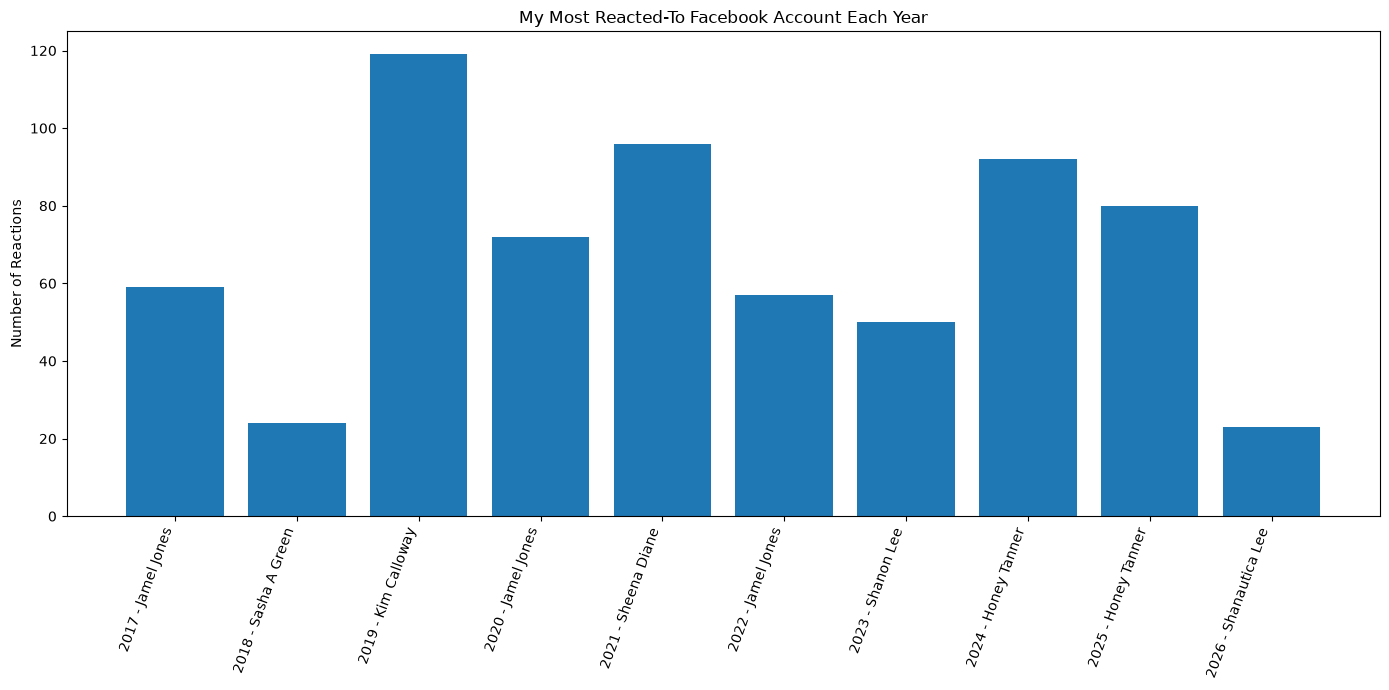

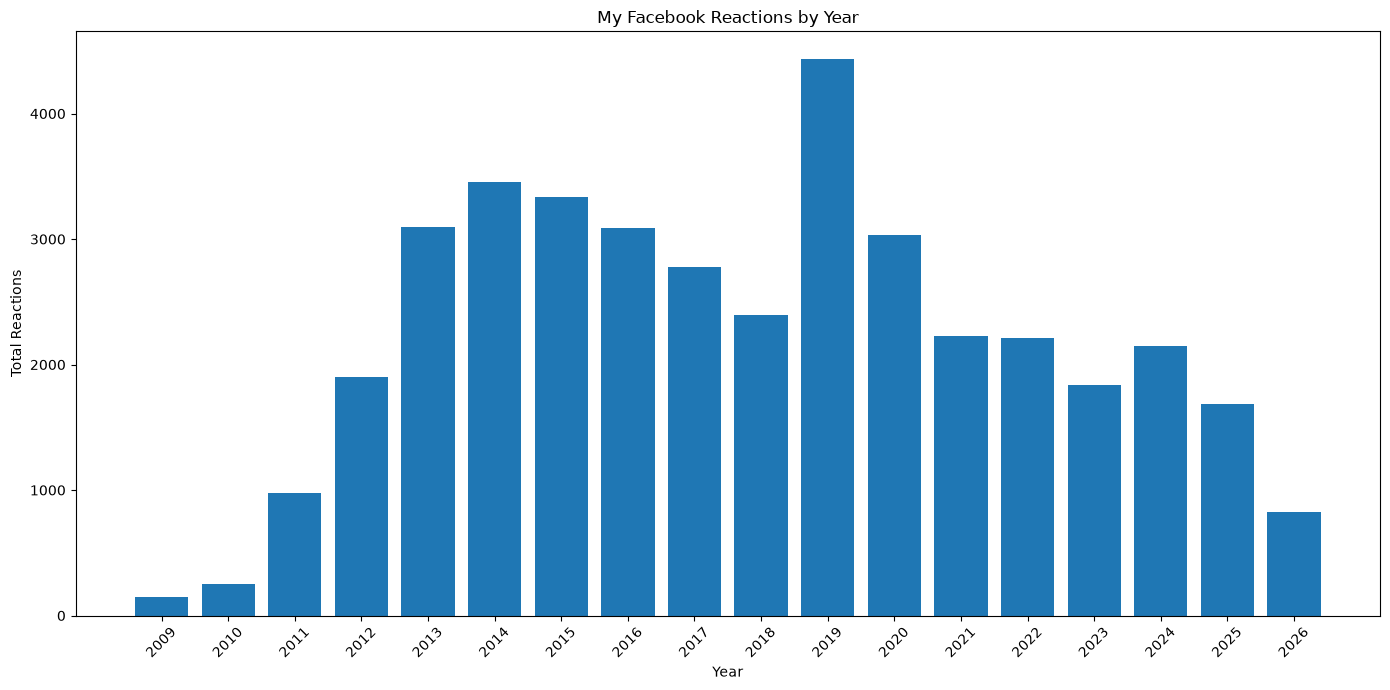

In [181]:
import matplotlib.pyplot as plt

# -----------------------------
# 1. TOP ACCOUNT FOR EACH YEAR
# -----------------------------

top_each_year = (
    likes_df[likes_df["final_account"].notna()]
    .groupby(["year", "final_account"])
    .size()
    .reset_index(name="reactions")
    .sort_values(["year", "reactions"], ascending=[True, False])
    .groupby("year")
    .first()
    .reset_index()
)

print("TOP ACCOUNT EACH YEAR")
print(top_each_year.to_string(index=False))


# -----------------------------
# 2. TOTAL REACTIONS EACH YEAR
# -----------------------------

reactions_by_year = (
    likes_df
    .groupby("year")
    .size()
    .reset_index(name="total_reactions")
)

most_active = reactions_by_year.loc[
    reactions_by_year["total_reactions"].idxmax()
]

print("\nYEAR WITH THE MOST REACTIONS")
print("Year:", int(most_active["year"]))
print("Reactions:", int(most_active["total_reactions"]))


# -----------------------------
# GRAPH 1
# Top account each year
# -----------------------------

plt.figure(figsize=(14, 7))

labels = (
    top_each_year["year"].astype(str)
    + " - "
    + top_each_year["final_account"]
)

plt.bar(labels, top_each_year["reactions"])

plt.title("My Most Reacted-To Facebook Account Each Year")
plt.ylabel("Number of Reactions")
plt.xticks(rotation=70, ha="right")
plt.tight_layout()
plt.show()


# -----------------------------
# GRAPH 2
# Total reactions each year
# -----------------------------

plt.figure(figsize=(14, 7))

plt.bar(
    reactions_by_year["year"].astype(str),
    reactions_by_year["total_reactions"]
)

plt.title("My Facebook Reactions by Year")
plt.xlabel("Year")
plt.ylabel("Total Reactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Conclusion

The results show that the Facebook account I reacted to the most changed over time. Jamel Jones was the top account in 2017, 2020, and 2022, while Honey Tanner was the top account in both 2024 and 2025. Other years had different top accounts.
My Facebook activity also changed considerably over time. Based on the data, 2019 had the highest number of reactions, with 4,434. Overall, my activity was much lower in the earliest years, increased substantially in the following years, and varied from year to year afterward.
These results answer my questions by showing both which accounts I interacted with the most each year and how my overall Facebook activity changed from 2009 through 2026.